In [1]:
import tifffile as tif
import matplotlib.pyplot as plt
import napari
import numpy as np
import skimage as skimage
import scipy as sp

In [7]:
# ------------------------------------------------------------------------------
# STEP 1: LOAD SHIT
# ------------------------------------------------------------------------------

# Set path
data_path = '../data/'

# Load larva mask
larva_mask = tif.memmap(data_path + 'fly_mask.tif')

# Check shape
print(f"Larva mask shape: {larva_mask.shape}")

# Check if binary (first frame)
print(f"Unique values in larva mask: {np.unique(larva_mask[0])}")

Larva mask shape: (571, 2048, 2048)
Unique values in larva mask: [  0 255]


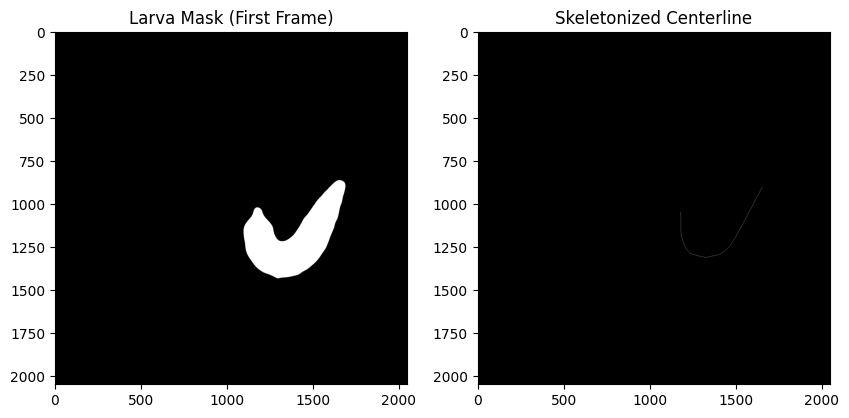

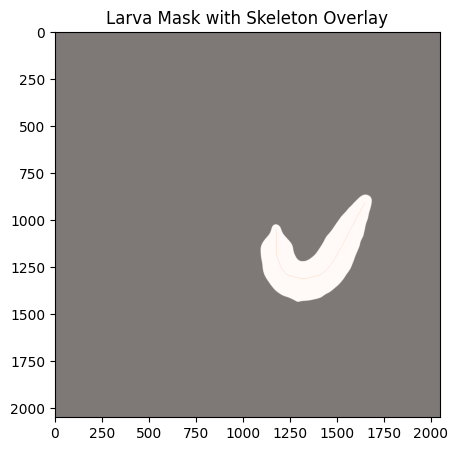

In [8]:
# ------------------------------------------------------------------------------
# STEP 2: SKELETONIZE AND VISUALIZE
# ------------------------------------------------------------------------------

frame = 225  # Change this to visualize different frames

# Skeletonize the larva mask to extract the midline
skeleton = skimage.morphology.skeletonize(larva_mask[frame] > 0)

# # Visualize the skeleton using napari
# viewer = napari.Viewer()
# viewer.add_image(larva_mask[frame], name='Larva Mask', colormap='gray')
# viewer.add_image(skeleton, name='Skeleton', colormap='red', opacity=0.5)
# napari.run()

# Plot the first frame of the larva mask and the skeleton
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(larva_mask[frame], cmap='gray')
plt.title('Larva Mask (First Frame)')
plt.subplot(1, 2, 2)
plt.imshow(skeleton, cmap='gray')
plt.title('Skeletonized Centerline')
plt.show()

# Overlay the skeleton on the larva mask
plt.figure(figsize=(5, 5))
plt.imshow(larva_mask[frame], cmap='gray')
plt.imshow(skeleton, cmap='Reds', alpha=0.5)
plt.title('Larva Mask with Skeleton Overlay')
plt.show()

In [9]:
# ------------------------------------------------------------------------------
# STEP 3: Label head and tail pixels on skeleton
# ------------------------------------------------------------------------------

# Set kernel
kernel = np.ones((3,3))
kernel[1,1] = 0 # Make center 0

# Convolve kernel with skeleton to find neighbors
convolved_mask = sp.ndimage.convolve(skeleton.astype(int), kernel) # Head and tail are 1, intermediate pixels are like 2 or 3 or whatever
print(f"Convolved Image Shape: {convolved_mask.shape}") # Output should be 2048 x 2048 (just convolved image, one slice for now)

# Choose head and tail pixels based on neighbor count
endpoints = np.argwhere((skeleton) & (convolved_mask == 1)) # So convolved head and tail pixels should be = 1, which is the same in the original binary mask (i.e. True = 1)
print(f"Endpoints Shape: {len(endpoints)}") # Output should be a list of coordinates of the head and tail pixels (i.e. [[y1, x1], [y2, x2]]).

Convolved Image Shape: (2048, 2048)
Endpoints Shape: 2


In [10]:
# ------------------------------------------------------------------------------
# STEP 4: Label all pixels along skeleton from tail --> head
# ------------------------------------------------------------------------------

def trace_skeleton(skeleton, starting_pixel, ending_pixel):
    '''
    Label pixels from tail to head
    
    PARAMETERS
        1.) skeleton: An array of coordinate pairs for every pixel in the skeleton
        2.) starting_pixel: The coordinates of the starting pixel
        3.) ending_pixel: The coordinates of the ending pixel
        
    RETURNS
        An array of skeleton coordinates, ordered from start to finish left to right
    '''
    
    #* Initialize variables
    visited = [] # Array of coordinates of visited pixels
    
    # --------------------------------------------------------------------------
    #* Main computation
    
    # Add starting point
    visited.append(tuple(starting_pixel))
    
    # Set current pixel to starting pixel
    current_pixel = tuple(starting_pixel)
    
    while current_pixel != ending_pixel:
        
        y, x = current_pixel # Get the x and y coordinates of the current pixel
        found_neighbor = False # Assume no neighbor is found yet
        
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                
                # If both dy and dx are 0 (i.e. center of the 8 pixel ring), then skip the current pixel itself. Break the entire inner loop and continue to the next iteration of the outer loop.
                if dy == 0 and dx == 0:
                    continue
                
                neighbor_pixel = (y + dy, x + dx)
                
                # Otherwise, if 4 conditions all hold, then move to the next unvisited pixel. Break the entire inner loop and continue to the next iteration of the outer loop.
                if (0 <= neighbor_pixel[0] < skeleton.shape[0] and 0 <= neighbor_pixel[1] < skeleton.shape[1] # Check if neighbor pixel is within bounds of the image
                        and skeleton[neighbor_pixel] # Check if neighbor pixel is part of the skeleton
                        and neighbor_pixel not in visited # Check if neighbor pixel has not been visited yet
                    ):
                    
                    # Move to the next unvisited pixel
                    current_pixel = neighbor_pixel
                    visited.append(current_pixel)
                    
                    found_neighbor = True # Set flag to True since a neighbor was found
                    
                    break  # Break the inner loop if a neighbor is found
                
            if found_neighbor:
                break  # Break the outer loop too if a neighbor is found
            
        #! print(visited)
            
        if not found_neighbor:
            print("No unvisited neighbors found. Stopping trace.")
            break  # Stop if no unvisited neighbors are found
        
        # ----------------------------------------------------------------------
        #* Return values
    
    return visited

# Define starting and ending pixels
starting_pixel = tuple(endpoints[0])  # Starting pixel
ending_pixel = tuple(endpoints[1])    # Ending pixel

# Trace the skeleton from the starting pixel to the ending pixel
labeled_skeleton = trace_skeleton(skeleton, starting_pixel, ending_pixel)

# Print the labeled skeleton coordinates
print(f"Labeled Skeleton Coordinates: {labeled_skeleton}")

Labeled Skeleton Coordinates: [(905, 1650), (906, 1650), (907, 1649), (908, 1648), (909, 1648), (910, 1647), (911, 1646), (912, 1646), (913, 1645), (914, 1645), (915, 1644), (916, 1643), (917, 1643), (918, 1642), (919, 1642), (920, 1641), (921, 1640), (922, 1640), (923, 1639), (924, 1639), (925, 1638), (926, 1638), (927, 1637), (928, 1637), (929, 1636), (930, 1635), (931, 1635), (932, 1634), (933, 1634), (934, 1633), (935, 1633), (936, 1632), (937, 1632), (938, 1631), (939, 1631), (940, 1631), (941, 1630), (942, 1629), (943, 1629), (944, 1629), (945, 1628), (946, 1627), (947, 1627), (948, 1627), (949, 1626), (950, 1625), (951, 1625), (952, 1624), (953, 1624), (954, 1624), (955, 1623), (956, 1622), (957, 1622), (958, 1621), (959, 1620), (960, 1620), (961, 1619), (962, 1619), (963, 1618), (964, 1617), (965, 1617), (966, 1616), (967, 1615), (968, 1615), (969, 1614), (970, 1614), (971, 1613), (972, 1612), (973, 1612), (974, 1611), (975, 1610), (976, 1610), (977, 1609), (978, 1609), (979, 1

In [11]:
# print(len(labeled_skeleton)) # Output should be the number of pixels in the skeleton (i.e. length of the midline)

# plt.figure(figsize=(5,5))
# plt.imshow(skeleton, cmap="gray")

# skeleton_y = [p[0] for p in labeled_skeleton]
# skeleton_x = [p[1] for p in labeled_skeleton]

# plt.plot(skeleton_x, skeleton_y)
# plt.axis("off")

# Visualize in napari
napari_viewer = napari.Viewer()
napari_viewer.add_image(larva_mask[frame], name='Larva Mask', colormap='gray')
napari_viewer.add_image(skeleton, name='Skeleton', colormap='red', opacity=0.5)
napari_viewer.add_points(np.array(labeled_skeleton), name='Labeled Skeleton', size=1, face_color='blue')
napari.run()

In [ ]:
# NOW CONVERT FOR ALL FRAMES

# for current_frame in range(larva_mask.shape[0]):
#     # Skeletonize the larva mask to extract the centerline
#     skeleton = skimage.morphology.skeletonize(larva_mask[current_frame] > 0)

#     # Convolve kernel with skeleton to find neighbors
#     convolved_mask = sp.ndimage.convolve(skeleton.astype(int), kernel)

#     # Choose head and tail pixels based on neighbor count
#     endpoints = np.argwhere((skeleton) & (convolved_mask == 1))
#     endpoints = [tuple(point) for point in endpoints]

#     # Define starting and ending pixels
#     starting_pixel = tuple(endpoints[0])  # Starting pixel
#     ending_pixel = tuple(endpoints[1])    # Ending pixel

#     # Trace the skeleton from the starting pixel to the ending pixel
#     labeled_skeleton = trace_skeleton(skeleton, starting_pixel, ending_pixel)

#     # Print the labeled skeleton coordinates for each frame
#     print(f"Frame {current_frame}: Labeled Skeleton Coordinates: {labeled_skeleton}")

: 